[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/notebooks/L1B2_caixa_de_ferramentas.ipynb)

# Notebook 00 — A Caixa de Ferramentas
### JAX, redes neurais do zero e com bibliotecas
**I Escola de Inverno do IFUSP — Bloco L1B2**

> **Modo de uso:** demo guiada pelo instrutor; vocês recebem o notebook depois.
> Ao final, vocês terão construído e treinado uma rede neural para regressão
> — primeiro na mão (JAX puro), depois com Equinox + Optax.

## O que é este ambiente?

**Google Colab** roda Python num servidor remoto, direto do navegador.
O documento é um *notebook Jupyter*:

- **Células de código** (fundo cinza): `Shift+Enter` para executar.
- **Células de texto** (como esta): explicações em Markdown.

Cada célula executada mantém o estado: variáveis ficam disponíveis nas seguintes.

In [ ]:
# Instalação de pacotes (só no Colab — localmente já estão instalados)
import subprocess, sys
try:
    import google.colab  # noqa: F401
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "jax", "jaxlib", "equinox", "optax", "matplotlib"])
except ImportError:
    pass

In [ ]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Semente de reprodutibilidade
SEED = 42
KEY = jax.random.PRNGKey(SEED)

# Estilo dos gráficos
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9})

print(f"JAX versão  : {jax.__version__}")
print(f"Dispositivo : {jax.devices()[0]}")

JAX versão  : 0.6.2
Dispositivo : cuda:0


---
## 1. Backbone matemático em JAX — arrays, shapes, broadcasting

Toda rede neural, no fundo, é uma sequência de **multiplicações de matrizes**
seguidas de funções não-lineares. Por isso, o primeiro passo é dominar arrays
e suas operações. Fazemos tudo com `jax.numpy` (abreviado `jnp`).

### Criando arrays

In [3]:
# Criando arrays com jax.numpy
vetor = jnp.array([1.0, 2.0, 3.0])
print("vetor       :", vetor)
print("vetor.shape :", vetor.shape)    # (3,) — um vetor com 3 elementos
print("vetor.dtype :", vetor.dtype)    # float32 — padrão do JAX
print()

# Funções utilitárias
zeros = jnp.zeros(5)
uns   = jnp.ones((2, 3))              # matriz 2x3 de uns
grade = jnp.linspace(0, 10, 5)        # 5 pontos igualmente espaçados
print("zeros       :", zeros)
print("uns         :\n", uns)
print("grade       :", grade)

vetor       : [1. 2. 3.]
vetor.shape : (3,)
vetor.dtype : float32

zeros       : [0. 0. 0. 0. 0.]
uns         :
 [[1. 1. 1.]
 [1. 1. 1.]]
grade       : [ 0.   2.5  5.   7.5 10. ]


### Broadcasting — operações entre arrays de tamanhos diferentes

Quando operamos um escalar com um vetor, o JAX "estica" automaticamente
o escalar para ter o mesmo tamanho. Essa regra se generaliza para
dimensões maiores — é o **broadcasting**.

In [4]:
# Regra 1: escalar + vetor — o escalar é "esticado"
T_celsius = jnp.array([20.1, 21.5, 19.8, 22.3])
T_kelvin  = T_celsius + 273.15   # 273.15 (shape ()) → esticado para shape (4,)

print("T_celsius.shape :", T_celsius.shape)
print("273.15 (escalar) é esticado para (4,)")
print("T_kelvin        :", T_kelvin)

T_celsius.shape : (4,)
273.15 (escalar) é esticado para (4,)
T_kelvin        : [293.25    294.65    292.94998 295.44998]


In [5]:
# Regra 2: duas dimensões compatíveis — ambas são esticadas
coluna = jnp.array([[1.0],
                     [2.0],
                     [3.0]])          # shape (3, 1)
linha  = jnp.array([[10, 20, 30, 40]])  # shape (1, 4)

print("coluna.shape :", coluna.shape, " — 3 linhas, 1 coluna")
print("linha.shape  :", linha.shape, " — 1 linha, 4 colunas")
print()

resultado = coluna + linha   # (3,1) + (1,4) → (3,4)
print("coluna + linha → shape", resultado.shape)
print(resultado)

coluna.shape : (3, 1)  — 3 linhas, 1 coluna
linha.shape  : (1, 4)  — 1 linha, 4 colunas

coluna + linha → shape (3, 4)
[[11. 21. 31. 41.]
 [12. 22. 32. 42.]
 [13. 23. 33. 43.]]


### Produtos de matrizes — a operação central do ML

Uma camada de rede neural faz essencialmente: $\mathbf{h} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$.
Vamos ver as várias formas de multiplicar matrizes em JAX.

In [6]:
M = jnp.array([[1.0, 2.0],
               [3.0, 4.0]])
v = jnp.array([1.0, 0.5])

# Produto matriz-vetor
print("M @ v              :", M @ v)
print("jnp.dot(M, v)      :", jnp.dot(M, v))
print("einsum('ij,j->i')  :", jnp.einsum('ij,j->i', M, v))
print()

# Produto de matrizes
N = jnp.array([[0.5, 0.0],
               [0.0, 2.0]])
print("M @ N (produto de matrizes):\n", M @ N)
print()

# CUIDADO: * é elemento a elemento, NÃO é produto de matrizes!
print("M * N (elemento a elemento — diferente de M @ N!):\n", M * N)

M @ v              : [2. 5.]
jnp.dot(M, v)      : [2. 5.]
einsum('ij,j->i')  : [2. 5.]

M @ N (produto de matrizes):
 [[0.5 4. ]
 [1.5 8. ]]

M * N (elemento a elemento — diferente de M @ N!):
 [[0.5 0. ]
 [0.  8. ]]


---
## 2. CPU vs GPU — por que ML ficou viável

A GPU (*Runtime > Change runtime type* no Colab) tem **milhares de
processadores simples em paralelo**, ideais para multiplicar matrizes grandes.
É isso que torna o treino de redes neurais possível.

In [7]:
TAMANHO = 2000  # matriz 2000 x 2000

A_mat = jax.random.normal(jax.random.PRNGKey(0), (TAMANHO, TAMANHO))
B_mat = jax.random.normal(jax.random.PRNGKey(1), (TAMANHO, TAMANHO))

# Primeira chamada compila o kernel — descartamos
_ = (A_mat @ B_mat).block_until_ready()

# Agora medimos
t0 = time.perf_counter()
_ = (A_mat @ B_mat).block_until_ready()
dt = time.perf_counter() - t0

dispositivo = jax.devices()[0].device_kind
print(f"Multiplicação {TAMANHO}x{TAMANHO}")
print(f"  Dispositivo : {dispositivo}")
print(f"  Tempo       : {dt*1e3:.1f} ms")
print()
print("No Colab com GPU, este mesmo cálculo leva <5 ms — 50-100x mais rápido!")

Multiplicação 2000x2000
  Dispositivo : NVIDIA GeForce RTX 3060
  Tempo       : 1.6 ms

No Colab com GPU, este mesmo cálculo leva <5 ms — 50-100x mais rápido!


---
## 3. Matplotlib — nosso primeiro gráfico

Vamos plotar uma **senoide amortecida** — a função que usaremos
como alvo ao longo de todo o notebook:

$$y = A\,\sin\!\left(\frac{2\pi x}{\lambda}\right)\,e^{-x/\tau}$$

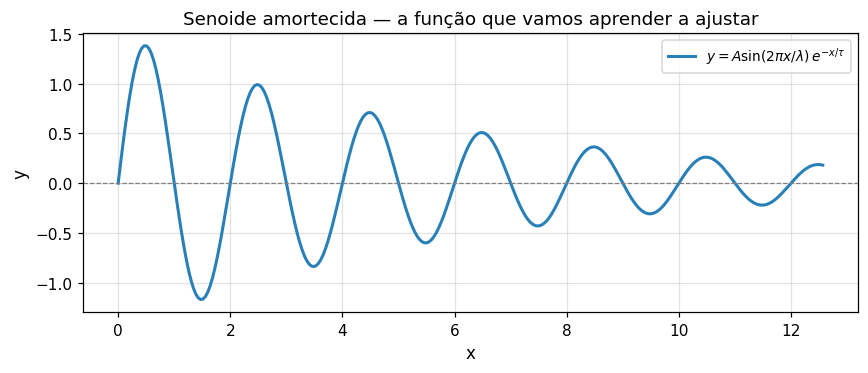

In [8]:
def senoide_amortecida(x, A=1.5, lam=2.0, tau=6.0):
    """Senoide amortecida — a função-alvo do nosso exercício."""
    return A * jnp.sin(2.0 * jnp.pi * x / lam) * jnp.exp(-x / tau)


x_plot = jnp.linspace(0, 4 * jnp.pi, 300)
y_plot = senoide_amortecida(x_plot)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x_plot, y_plot, lw=2, color="#2980b9", label=r"$y = A\sin(2\pi x/\lambda)\,e^{-x/\tau}$")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Senoide amortecida — a função que vamos aprender a ajustar")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## 🟣 (Opcional) Diferenciação automática — `jax.grad`

> Esta seção é opcional. Execute se houver tempo.

O JAX calcula **derivadas exatas** de qualquer função Python com `jax.grad`.
É isto que torna o treino de redes neurais possível.

In [9]:
# Exemplo simples: f(x) = x²  →  f'(x) = 2x
def f(x):
    return x ** 2

df_dx = jax.grad(f)   # df_dx é uma FUNÇÃO Python!

print("f(x) = x²")
print(f"f'(3.0) = {df_dx(3.0):.1f}   (esperado: 2 x 3 = 6.0)")
print(f"f'(5.0) = {df_dx(5.0):.1f}   (esperado: 2 x 5 = 10.0)")

f(x) = x²
f'(3.0) = 6.0   (esperado: 2 x 3 = 6.0)
f'(5.0) = 10.0   (esperado: 2 x 5 = 10.0)


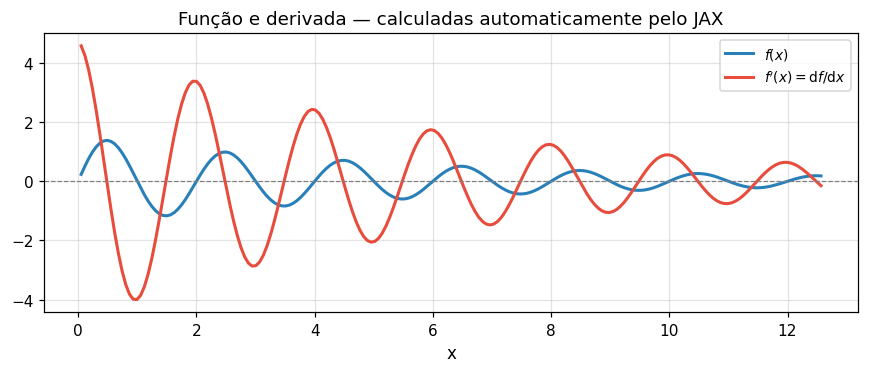

jax.grad calculou a derivada EXATA — sem fórmula analítica!
É isto que usaremos para treinar redes neurais:
  derivar a perda em relação aos PESOS do modelo.


In [10]:
# Derivada da senoide amortecida em relação a x
# jax.vmap aplica a função a cada elemento do array automaticamente
df_senoide = jax.vmap(jax.grad(senoide_amortecida))

x_ad = jnp.linspace(0.05, 4.0 * jnp.pi, 200)
y_ad = senoide_amortecida(x_ad)
dy_ad = df_senoide(x_ad)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x_ad, y_ad, lw=2, color="#2980b9", label=r"$f(x)$")
ax.plot(x_ad, dy_ad, lw=2, color="#e74c3c", label=r"$f'(x) = \mathrm{d}f/\mathrm{d}x$")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("x")
ax.set_title("Função e derivada — calculadas automaticamente pelo JAX")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print("jax.grad calculou a derivada EXATA — sem fórmula analítica!")
print("É isto que usaremos para treinar redes neurais:")
print("  derivar a perda em relação aos PESOS do modelo.")

---
## 🟣 (Opcional) `jax.jit` e `jax.vmap`

> Seção opcional. Estes são dois "superpoderes" do JAX:
>
> - `jax.jit` — compila a função para XLA, acelerando 10-100x.
> - `jax.vmap` — vetoriza automaticamente sobre um eixo de batch.

In [11]:
# ── jax.jit: compilação para XLA ─────────────────────────────────────────────
def somar_quadrados(x):
    return jnp.sum(x ** 2)

somar_jit = jax.jit(somar_quadrados)

v_grande = jnp.ones(10_000_000)
_ = somar_jit(v_grande).block_until_ready()   # primeiro call compila

t0 = time.perf_counter()
_ = somar_quadrados(v_grande).block_until_ready()
dt_sem = time.perf_counter() - t0

t0 = time.perf_counter()
_ = somar_jit(v_grande).block_until_ready()
dt_com = time.perf_counter() - t0

print(f"Sem jit : {dt_sem*1e3:.2f} ms")
print(f"Com jit : {dt_com*1e3:.2f} ms")
print(f"Aceleração: {dt_sem/max(dt_com, 1e-9):.1f}x")

# ── jax.vmap: vetorização automática ─────────────────────────────────────────
print()

def distancia(a, b):
    return jnp.sqrt(jnp.sum((a - b) ** 2))

dist_batch = jax.vmap(distancia, in_axes=(0, 0))

pts_a = jnp.array([[0.0, 0.0], [1.0, 1.0], [2.0, 3.0]])
pts_b = jnp.array([[1.0, 1.0], [4.0, 5.0], [2.0, 3.0]])
print("Distâncias (vmap):", dist_batch(pts_a, pts_b))

Sem jit : 52.69 ms
Com jit : 0.43 ms
Aceleração: 122.4x

Distâncias (vmap): [1.4142135 5.        0.       ]


---
## Exercício Central: Regressão com Rede Neural

Vamos construir e treinar uma **rede neural completamente conexa (FCNN)**
para ajustar a senoide amortecida com ruído gaussiano:

$$y = A \sin\!\left(\frac{2\pi x}{\lambda}\right) e^{-x/\tau} + \varepsilon,
   \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Parâmetros: $A = 1.5$, $\lambda = 2$, $\tau = 6$, $\sigma = 0.15$.

**Faremos o exercício duas vezes:**

| | Bloco A — do zero | Bloco B — com bibliotecas |
|---|---|---|
| Modelo | matrizes explícitas | `eqx.nn.MLP` (Equinox) |
| Forward | `h = tanh(x @ W + b)` | `modelo(x)` |
| Otimizador | SGD+momentum na mão | `optax.adam` (Optax) |

Ao final, demonstramos **sobreajuste** com uma rede grande demais.

### Gerar os dados

In [12]:
# ── Parâmetros ────────────────────────────────────────────────────────────────
N_DADOS  = 200
SIGMA_EP = 0.15
X_MAX    = 4.0 * jnp.pi

# ── Gerar dados ──────────────────────────────────────────────────────────────
key_dados, k_x, k_ruido = jax.random.split(KEY, 3)

x_dados      = jnp.sort(jax.random.uniform(k_x, (N_DADOS,), minval=0.0, maxval=float(X_MAX)))
y_verdadeiro = senoide_amortecida(x_dados)
ruido        = jax.random.normal(k_ruido, (N_DADOS,)) * SIGMA_EP
y_ruidoso    = y_verdadeiro + ruido

# ── Normalizar x para [-1, 1] (essencial para ativações tanh) ────────────────
def normalizar_x(x):
    """Mapeia [0, X_MAX] para [-1, 1]."""
    return 2.0 * x / X_MAX - 1.0

x_norm = normalizar_x(x_dados)

# ── Preparar inputs para a rede: shape (N, 1) ────────────────────────────────
x_in = x_norm.reshape(-1, 1)
y_in = y_ruidoso

# ── Grid denso para plotar ───────────────────────────────────────────────────
x_grade = jnp.linspace(0.0, float(X_MAX), 500)
xg_in   = normalizar_x(x_grade).reshape(-1, 1)
y_grade = senoide_amortecida(x_grade)

print(f"Dados: {N_DADOS} pontos, x em [0, 4pi]")
print(f"Input normalizado: x_in.shape = {x_in.shape}")

Dados: 200 pontos, x em [0, 4pi]
Input normalizado: x_in.shape = (200, 1)


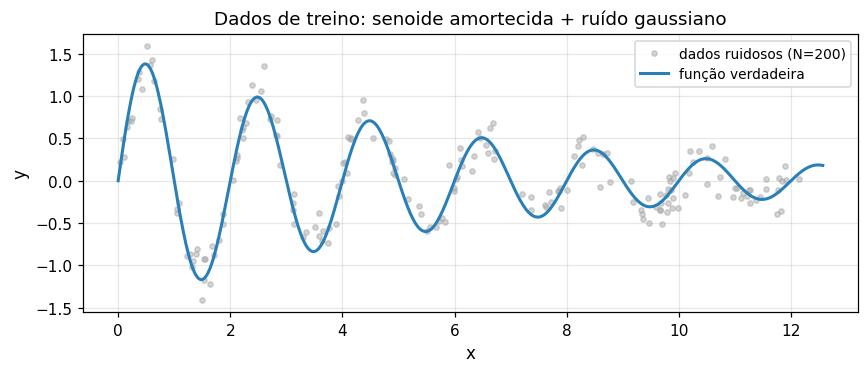

Piso do ruído (sigma² = 0.0225) — nenhum modelo deveria ter perda menor.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(x_dados, y_ruidoso, s=12, alpha=0.5, color="#aaaaaa", label=f"dados ruidosos (N={N_DADOS})", zorder=2)
ax.plot(x_grade, y_grade, "-", lw=2, color="#2980b9", label="função verdadeira", zorder=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Dados de treino: senoide amortecida + ruído gaussiano")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Piso do ruído (sigma² = {SIGMA_EP**2:.4f}) — nenhum modelo deveria ter perda menor.")

---
## Bloco A — FCNN do zero

Vamos construir tudo explicitamente: pesos, forward pass, perda, gradiente,
e o loop de treino.

### Inicialização dos pesos

Os parâmetros são uma lista de tuplas $(W, b)$, uma por camada.
Usamos inicialização de **Glorot**: escala proporcional ao tamanho das camadas.

In [ ]:
def init_params(camadas, chave):
    """Cria pesos (W, b) para cada camada com inicialização de Glorot."""
    params = []
    for i in range(len(camadas) - 1):
        chave, k = jax.random.split(chave)
        n_in, n_out = camadas[i], camadas[i + 1]
        escala = jnp.sqrt(6.0 / (n_in + n_out))
        W = jax.random.uniform(k, (n_in, n_out), minval=-escala, maxval=escala)
        b = jnp.zeros(n_out)
        params.append((W, b))
    return params

# Rede
CAMADAS = [1, 16, 16, 16, 1]
params_a = init_params(CAMADAS, jax.random.PRNGKey(0))

print("Rede", CAMADAS)
for i, (W, b) in enumerate(params_a):
    print(f"  Camada {i}: W {W.shape}, b {b.shape}")
total = sum(W.size + b.size for W, b in params_a)
print(f"  Total: {total} parâmetros")

Rede [1, 16, 16, 16, 1]
  Camada 0: W (1, 16), b (16,)
  Camada 1: W (16, 16), b (16,)
  Camada 2: W (16, 16), b (16,)
  Camada 3: W (16, 1), b (1,)
  Total: 593 parâmetros


### Forward pass

Cada camada oculta aplica: $\mathbf{h} = \tanh(\mathbf{h}\,\mathbf{W} + \mathbf{b})$.
A camada de saída é linear (sem ativação).

In [15]:
def forward(params, x):
    """Forward pass: tanh nas ocultas, linear na saída."""
    h = x
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W_out, b_out = params[-1]
    return h @ W_out + b_out

# Teste rápido
y_teste = forward(params_a, x_in[:5])
print(f"Input  : shape {x_in[:5].shape}")
print(f"Output : shape {y_teste.shape}")
print(f"Predições iniciais (devem ser pequenas): {y_teste.squeeze()}")

Input  : shape (5, 1)
Output : shape (5, 1)
Predições iniciais (devem ser pequenas): [-0.30326986 -0.30120814 -0.30067915 -0.2982636  -0.29800603]


### Função de perda — MSE

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

É esta função que `jax.grad` vai diferenciar.

In [ ]:
def perda_mse(params, x_batch, y_batch):
    """Erro quadrático médio."""
    y_pred = forward(params, x_batch).squeeze(-1)
    return jnp.mean((y_pred - y_batch) ** 2)

perda_ini = float(perda_mse(params_a, x_in, y_in))
var_y     = float(jnp.var(y_in))
print(f"Perda inicial (modelo aleatório) : {perda_ini:.4f}")
print(f"Variância de y_ruidoso           : {var_y:.4f}")
print("(Esperado: perda próxima da variância quando o modelo prevê ~0)")

Perda inicial (modelo aleatório) : 0.3585
Variância de y_ruidoso           : 0.2881
(Esperado: perda próxima da variância quando o modelo prevê ~0)


### Treino — SGD com momentum e mini-batches

A cada passo, calculamos o gradiente num mini-batch e atualizamos os pesos.
Usamos **momentum** — uma "memória" dos gradientes anteriores que suaviza
o caminho e acelera a convergência:

$$\mathbf{v} \leftarrow \beta\,\mathbf{v} + \nabla\mathcal{L}$$
$$\mathbf{W} \leftarrow \mathbf{W} - \eta\,\mathbf{v}$$

Sem momentum ($\beta = 0$), o SGD puro converge muito lentamente para
redes com muitas camadas.

In [17]:
N_EPOCAS_A = 4000
LR_A       = 0.05      # taxa de aprendizado
MOMENTUM   = 0.9       # coeficiente de momentum
BATCH_SIZE = 50

EPOCAS_FOTO = list(jnp.linspace(0, N_EPOCAS_A, 4, dtype=jnp.int32))  # snapshots para a "figura-troféu"

# Função de gradiente compilada (jit acelera o cálculo)
grad_fn = jax.jit(jax.grad(perda_mse))

# Inicializar velocidade (mesma estrutura dos params, tudo zero)
vel_a = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params_a]

# Guardar snapshots e histórico de perda
fotos_a     = {0: list(params_a)}   # snapshot antes do treino
historico_a = []

chave_treino = jax.random.PRNGKey(1)

print(f"Treinando {N_EPOCAS_A} épocas — SGD+momentum (lr={LR_A}, mom={MOMENTUM}, batch={BATCH_SIZE})")
print(f"{'Época':>8}  {'Perda':>10}")
print("-" * 22)

t0 = time.perf_counter()
for epoca in range(1, N_EPOCAS_A + 1):
    # Embaralhar
    chave_treino, chave_perm = jax.random.split(chave_treino)
    perm  = jax.random.permutation(chave_perm, N_DADOS)
    x_emb = x_in[perm]
    y_emb = y_in[perm]

    # Mini-batches
    for i in range(0, N_DADOS, BATCH_SIZE):
        x_b = x_emb[i:i + BATCH_SIZE]
        y_b = y_emb[i:i + BATCH_SIZE]
        grads = grad_fn(params_a, x_b, y_b)

        # Atualização com momentum — escrita explicitamente
        vel_a = [(MOMENTUM * vW + dW, MOMENTUM * vb + db) for (vW, vb), (dW, db) in zip(vel_a, grads)]
        params_a = [(W - LR_A * vW, b - LR_A * vb) for (W, b), (vW, vb) in zip(params_a, vel_a)]

    # Snapshot
    if epoca in EPOCAS_FOTO:
        fotos_a[epoca] = list(params_a)

    # Monitorar
    if epoca % 100 == 0 or epoca == 1:
        perda = float(perda_mse(params_a, x_in, y_in))
        historico_a.append((epoca, perda))
        if epoca <= 1 or epoca % 500 == 0:
            print(f"{epoca:>8}  {perda:>10.6f}")

dt_a = time.perf_counter() - t0
perda_final_a = float(perda_mse(params_a, x_in, y_in))
print(f"\nConcluído em {dt_a:.1f}s")
print(f"Perda final   : {perda_final_a:.6f}")
print(f"Piso (sigma²) : {SIGMA_EP**2:.4f}")

Treinando 4000 épocas — SGD+momentum (lr=0.05, mom=0.9, batch=50)
   Época       Perda
----------------------
       1    0.329394
     500    0.076792
    1000    0.051379
    1500    0.037019
    2000    0.033077
    2500    0.025473
    3000    0.023597
    3500    0.023463
    4000    0.024687

Concluído em 18.3s
Perda final   : 0.024687
Piso (sigma²) : 0.0225


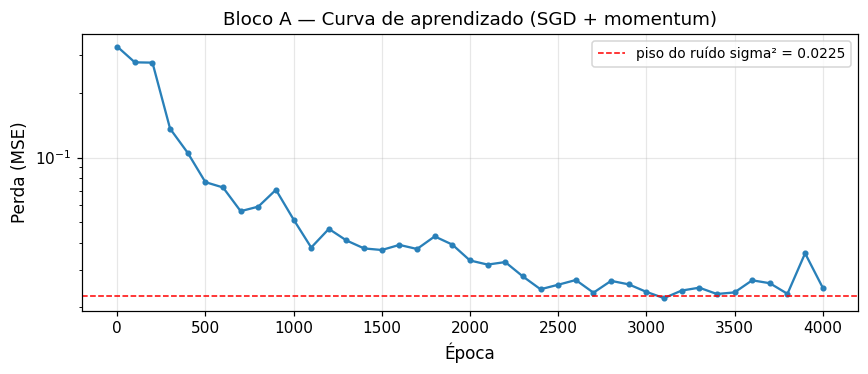

In [18]:
# Curva de aprendizado
epocas_h, perdas_h = zip(*historico_a)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(epocas_h, perdas_h, "-o", ms=3, color="#2980b9")
ax.axhline(SIGMA_EP**2, color="red", ls="--", lw=1, label=f"piso do ruído sigma² = {SIGMA_EP**2:.4f}")
ax.set_xlabel("Época")
ax.set_ylabel("Perda (MSE)")
ax.set_title("Bloco A — Curva de aprendizado (SGD + momentum)")
ax.legend()
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Figura-troféu — o modelo aprendendo época a época

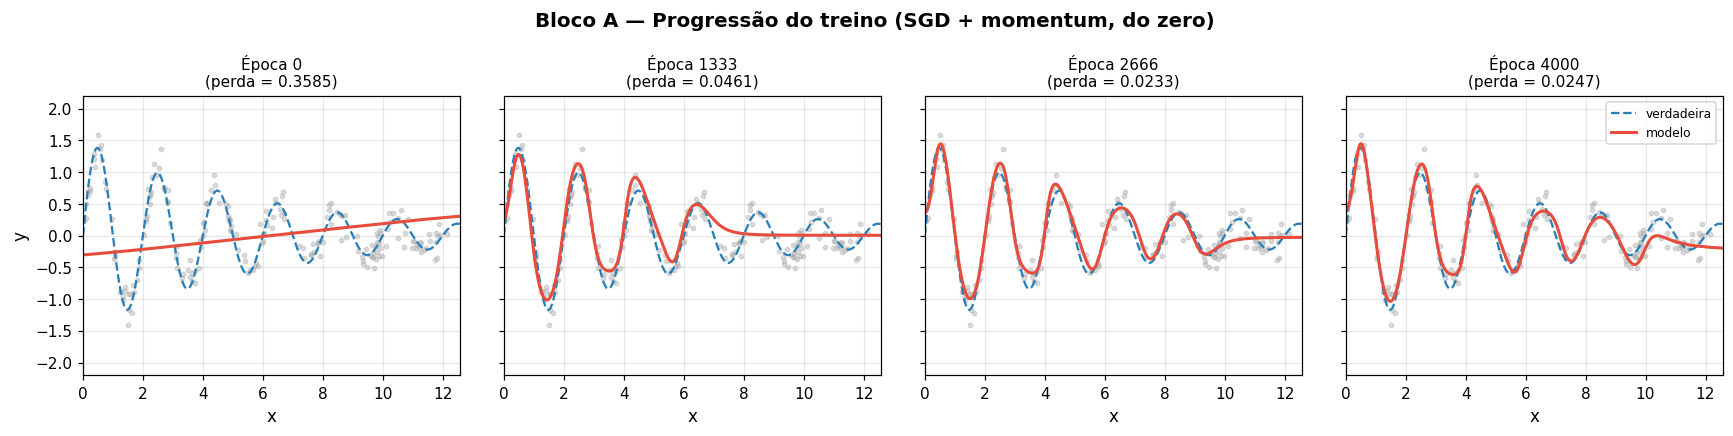

In [ ]:
fig, axes_trophy = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Bloco A — Progressão do treino (SGD + momentum, do zero)", fontsize=13, fontweight="bold")

for ax, ep in zip(axes_trophy, EPOCAS_FOTO):
    p_snap   = fotos_a[int(ep)]
    y_pred_s = forward(p_snap, xg_in).squeeze(-1)
    perda_s  = float(perda_mse(p_snap, x_in, y_in))

    ax.scatter(x_dados, y_ruidoso, s=8, alpha=0.4, color="#aaaaaa")
    ax.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9", label="verdadeira")
    ax.plot(x_grade, y_pred_s, "-",  lw=2.0, color="#e74c3c", label="modelo")
    ax.set_title(f"Época {ep}\n(perda = {perda_s:.4f})", fontsize=10)
    ax.set_xlabel("x")
    ax.set_xlim(0, float(X_MAX))
    ax.set_ylim(-2.2, 2.2)
    ax.grid(True, alpha=0.3)

axes_trophy[0].set_ylabel("y")
axes_trophy[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

---
## Bloco B — Mesmo exercício com Equinox + Optax

Agora reproduzimos o Bloco A usando duas bibliotecas do ecossistema JAX:

- **Equinox** — define modelos como módulos (encapsula `init_params` + `forward`)
- **Optax** — fornece otimizadores prontos (Adam, SGD com momentum, etc.)

| Bloco A (do zero) | Bloco B (bibliotecas) |
|---|---|
| `init_params(camadas, chave)` | `eqx.nn.MLP(...)` |
| `forward(params, x)` | `jax.vmap(modelo)(x)` |
| `jax.grad` + SGD+momentum manual | `eqx.filter_value_and_grad` + `optax.adam` |

### Definir o modelo

In [ ]:
import equinox as eqx
import optax

class MLP_Custom(eqx.Module):
    """MLP com camadas de tamanhos variáveis."""
    layers: list
    
    def __init__(self, camadas, key):
        self.layers = []
        for i in range(len(camadas) - 1):
            key, subkey = jax.random.split(key)
            n_in, n_out = camadas[i], camadas[i + 1]
            # Linear layer + activation (except last layer)
            self.layers.append(eqx.nn.Linear(n_in, n_out, key=subkey))
            if i < len(camadas) - 2:  # Don't add activation after last layer
                self.layers.append(jnp.tanh)
    
    def __call__(self, x):
        for layer in self.layers:
            if isinstance(layer, eqx.nn.Linear):
                x = layer(x)
            else:  # activation function
                x = layer(x)
        return x

# Criar o modelo com a mesma arquitetura
CAMADAS = [1, 16, 16, 16, 1]
modelo_b = MLP_Custom(CAMADAS, key=jax.random.PRNGKey(0))

# Teste
y_teste = jax.vmap(modelo_b)(x_in[:5])
print(f"Input  : shape {x_in[:5].shape}")
print(f"Output : shape {y_teste.shape}")
print(f"Predições iniciais: {y_teste.squeeze()}")

# Contar parâmetros (deve bater com o seu init_params)
total = sum(jnp.size(p) for p in jax.tree_util.tree_leaves(modelo_b))
print(f"Total: {total} parâmetros")

Input  : shape (5, 1)
Output : shape (5, 1)
Predições iniciais: [0.09400892 0.09459366 0.09475252 0.09528141 0.09541684]
Total: 596 parâmetros


/home/dlopez/tmp/pip-tmp/ipykernel_1001364/3853250089.py:37: DeprecationWarning: size requires ndarray or scalar arguments, got <class 'jaxlib._jax.PjitFunction'> at position 0. In a future JAX release this will be an error.
  total = sum(jnp.size(p) for p in jax.tree_util.tree_leaves(modelo_b))


### Perda, otimizador e passo de treino

In [21]:
def perda_eqx(modelo, x_batch, y_batch):
    """MSE — versão para modelo Equinox."""
    y_pred = jax.vmap(modelo)(x_batch).squeeze(-1)
    return jnp.mean((y_pred - y_batch) ** 2)

# Otimizador Adam — substitui o SGD+momentum manual
otimizador_b = optax.adam(learning_rate=5e-3)
opt_state_b  = otimizador_b.init(eqx.filter(modelo_b, eqx.is_array))

@eqx.filter_jit
def passo_b(modelo, estado, x, y):
    """Um passo de treino: gradiente + atualização Adam."""
    perda, grads = eqx.filter_value_and_grad(perda_eqx)(modelo, x, y)
    atualizacoes, estado = otimizador_b.update(grads, estado, modelo)
    modelo = eqx.apply_updates(modelo, atualizacoes)
    return modelo, estado, perda

### Loop de treino

In [22]:
N_EPOCAS_B  = 4000
historico_b = []
chave_b     = jax.random.PRNGKey(2)

print(f"Treinando {N_EPOCAS_B} épocas — Adam (lr=0.005, batch={BATCH_SIZE})")

t0 = time.perf_counter()
for epoca in range(1, N_EPOCAS_B + 1):
    chave_b, chave_perm = jax.random.split(chave_b)
    perm  = jax.random.permutation(chave_perm, N_DADOS)
    x_emb = x_in[perm]
    y_emb = y_in[perm]

    for i in range(0, N_DADOS, BATCH_SIZE):
        x_b = x_emb[i:i + BATCH_SIZE]
        y_b = y_emb[i:i + BATCH_SIZE]
        modelo_b, opt_state_b, _ = passo_b(modelo_b, opt_state_b, x_b, y_b)

    if epoca % 100 == 0 or epoca == 1:
        perda = float(perda_eqx(modelo_b, x_in, y_in))
        historico_b.append((epoca, perda))
        if epoca <= 1 or epoca % 500 == 0:
            print(f"  Época {epoca:4d}  perda = {perda:.6f}")

dt_b = time.perf_counter() - t0
perda_final_b = float(perda_eqx(modelo_b, x_in, y_in))
print(f"\nConcluído em {dt_b:.1f}s")
print(f"Perda final : {perda_final_b:.6f}")

Treinando 4000 épocas — Adam (lr=0.005, batch=50)
  Época    1  perda = 0.284413
  Época  500  perda = 0.058075
  Época 1000  perda = 0.035311
  Época 1500  perda = 0.032733
  Época 2000  perda = 0.031194
  Época 2500  perda = 0.026403
  Época 3000  perda = 0.023529
  Época 3500  perda = 0.019367
  Época 4000  perda = 0.018907

Concluído em 10.4s
Perda final : 0.018907


### Comparação: Bloco A vs Bloco B

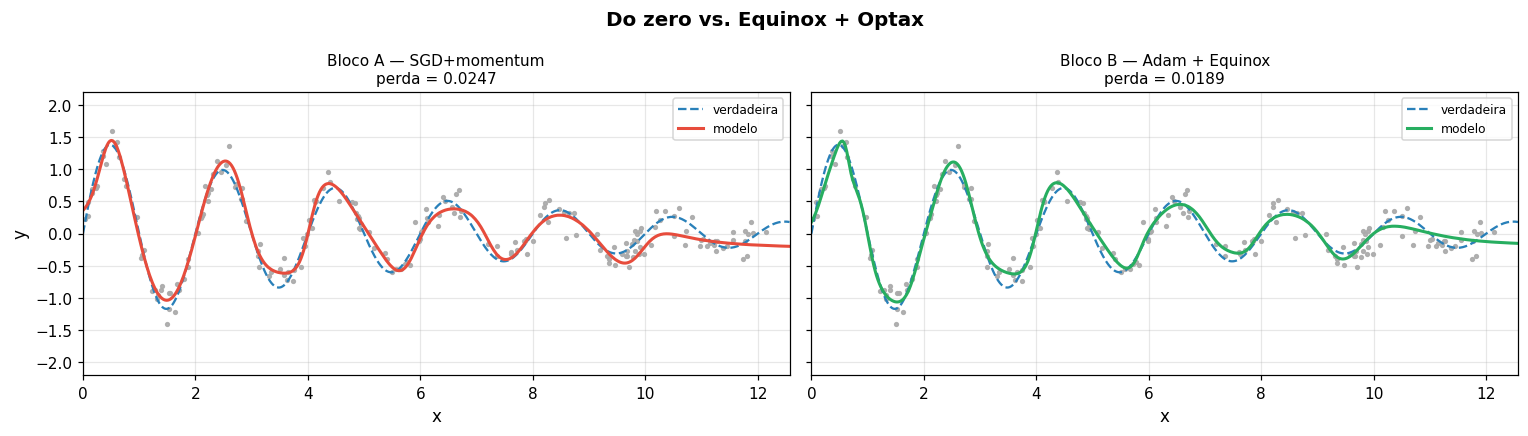

Ambos aprendem a mesma função — as bibliotecas simplificam o código,
não mudam a matemática subjacente!


In [ ]:
y_pred_a_plot = forward(params_a, xg_in).squeeze(-1)
y_pred_b_plot = jax.vmap(modelo_b)(xg_in).squeeze(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle("Do zero vs. Equinox + Optax", fontsize=13, fontweight="bold")

for ax, y_pred, titulo, cor in [
    (ax1, y_pred_a_plot, f"Bloco A — SGD+momentum\nperda = {perda_final_a:.4f}", "#e74c3c"),
    (ax2, y_pred_b_plot, f"Bloco B — Adam + Equinox\nperda = {perda_final_b:.4f}", "#27ae60"),
]:
    ax.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9", label="verdadeira")
    ax.plot(x_grade, y_pred, "-", lw=2, color=cor, label="modelo")
    ax.scatter(x_dados, y_ruidoso, s=6, alpha=0.9, color="#aaaaaa")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("x")
    ax.set_xlim(0, float(X_MAX))
    ax.set_ylim(-2.2, 2.2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax1.set_ylabel("y")
plt.tight_layout()
plt.show()

### Sobreajuste (*overfitting*)

In [24]:
# Rede grande com Equinox
CAMADAS = [1, 256, 256, 256, 1]
modelo_of = MLP_Custom(CAMADAS, key=jax.random.PRNGKey(0))

otimizador_of = optax.adam(learning_rate=1e-3)
opt_state_of  = otimizador_of.init(eqx.filter(modelo_of, eqx.is_array))

@eqx.filter_jit
def passo_of(modelo, estado, x, y):
    perda, grads = eqx.filter_value_and_grad(perda_eqx)(modelo, x, y)
    atualizacoes, estado = otimizador_of.update(grads, estado, modelo)
    modelo = eqx.apply_updates(modelo, atualizacoes)
    return modelo, estado, perda

N_EPOCAS_OF = 100000
print(f"Treinando rede grande por {N_EPOCAS_OF} épocas...")

t0 = time.perf_counter()
for epoca in range(1, N_EPOCAS_OF + 1):
    modelo_of, opt_state_of, perda_of = passo_of(modelo_of, opt_state_of, x_in, y_in)
    if epoca % 5000 == 0:
        print(f"  Época {epoca:5d}  perda = {float(perda_of):.6f}")

dt_of = time.perf_counter() - t0
perda_final_of = float(perda_eqx(modelo_of, x_in, y_in))
print(f"\nConcluído em {dt_of:.1f}s")
print(f"Perda final            : {perda_final_of:.6f}")
print(f"Piso do ruído (sigma²) : {SIGMA_EP**2:.4f}")

Treinando rede grande por 100000 épocas...
  Época  5000  perda = 0.016332
  Época 10000  perda = 0.015770
  Época 15000  perda = 0.014341
  Época 20000  perda = 0.013559
  Época 25000  perda = 0.012831
  Época 30000  perda = 0.010321
  Época 35000  perda = 0.009202
  Época 40000  perda = 0.007589
  Época 45000  perda = 0.006396
  Época 50000  perda = 0.005773
  Época 55000  perda = 0.005617
  Época 60000  perda = 0.006084
  Época 65000  perda = 0.005086
  Época 70000  perda = 0.004740
  Época 75000  perda = 0.004156
  Época 80000  perda = 0.003436
  Época 85000  perda = 0.003093
  Época 90000  perda = 0.002425
  Época 95000  perda = 0.002768
  Época 100000  perda = 0.002378

Concluído em 24.3s
Perda final            : 0.001904
Piso do ruído (sigma²) : 0.0225


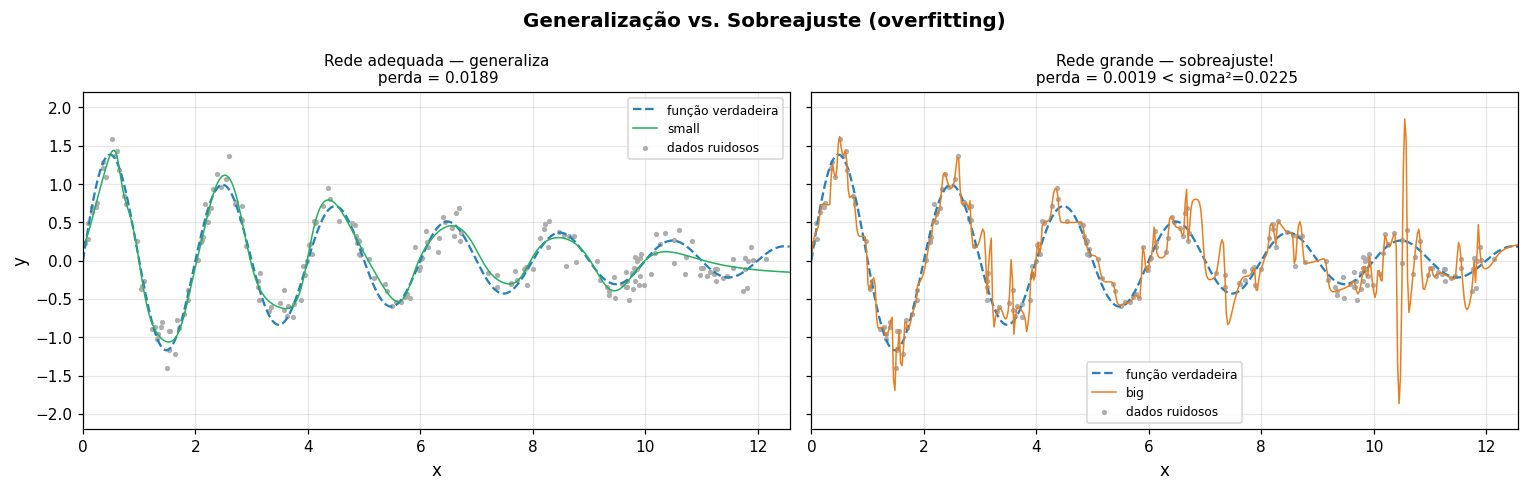

A rede grande memorizou o ruído — não generalizou.
Na quarta-feira, veremos o que acontece quando a distribuição
de TESTE é diferente da distribuição de TREINO.


In [ ]:
y_pred_bom = jax.vmap(modelo_b)(xg_in).squeeze(-1)
y_pred_of  = jax.vmap(modelo_of)(xg_in).squeeze(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
fig.suptitle("Generalização vs. Sobreajuste (overfitting)", fontsize=13, fontweight="bold")

# Rede adequada
ax1.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9", label="função verdadeira")
ax1.plot(x_grade, y_pred_bom, "-", lw=1, color="#27ae60", label="small")
ax1.scatter(x_dados, y_ruidoso, s=6, alpha=0.9, color="#aaaaaa", label="dados ruidosos")
ax1.set_title(f"Rede adequada — generaliza\n perda = {perda_final_b:.4f}", fontsize=10)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_xlim(0, float(X_MAX))
ax1.set_ylim(-2.2, 2.2)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Rede grande (sobreajuste)
ax2.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9", label="função verdadeira")
ax2.plot(x_grade, y_pred_of, "-", lw=1, color="#e67e22", label="big")
ax2.scatter(x_dados, y_ruidoso, s=6, alpha=0.9, color="#aaaaaa", label="dados ruidosos")
ax2.set_title(f"Rede grande — sobreajuste!\n perda = {perda_final_of:.4f} < sigma²={SIGMA_EP**2:.4f}", fontsize=10)
ax2.set_xlabel("x")
ax2.set_xlim(0, float(X_MAX))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Mapa de vocabulário

| O que fizemos | Jargão | Significado |
|---|---|---|
| Função alvo ruidosa | **tarefa** (task) | O que queremos que a rede aprenda |
| `init_params` / `eqx.nn.MLP` | **modelo** | A função parametrizada |
| `forward(params, x)` / `model(x)` | **inferência** | Aplicar o modelo a dados |
| `perda_mse` | **função de perda** | Mede o erro do modelo |
| `jax.grad(perda_mse)` | **gradiente** | Direção de subida mais íngreme |
| `W -= lr * vel` / `optax.adam` | **otimizador** | Regra de atualização dos pesos |
| Mini-batch | **SGD** | Gradiente estocástico (subconjunto dos dados) |
| Modelo que generaliza | **generalização** | O objetivo real |
| Modelo que memoriza ruído | **sobreajuste** (overfitting) | O que queremos evitar |
| Equinox | **framework de modelos** | Define redes como módulos |
| Optax | **biblioteca de otimizadores** | Fornece Adam, SGD, etc. |

> **Takeaway:** *Treinar uma rede = descer o gradiente de uma função de perda.*
> As bibliotecas (Equinox, Optax) encapsulam a matemática, mas o fundamento é o mesmo.

---
## Desempenho em dados de teste

Até aqui, avaliamos os modelos nos **mesmos dados** usados para treinar.
Mas o objetivo real é **generalizar** para dados novos.
Vamos gerar um conjunto de teste independente (mesma distribuição, ruído
novo) e comparar os dois modelos.

In [ ]:
# ── Gerar dados de teste (mesma distribuição, semente diferente) ─────────────
k_test_x, k_test_ruido = jax.random.split(jax.random.PRNGKey(123))

x_teste = jnp.sort(jax.random.uniform(k_test_x, (N_DADOS,), minval=0.0, maxval=float(X_MAX)))
y_teste_ruidoso = senoide_amortecida(x_teste) + jax.random.normal(k_test_ruido, (N_DADOS,)) * SIGMA_EP

x_teste_in = normalizar_x(x_teste).reshape(-1, 1)

# ── Perda de teste para cada modelo ─────────────────────────────────────────
perda_teste_small = float(perda_eqx(modelo_b, x_teste_in, y_teste_ruidoso))
perda_teste_big   = float(perda_eqx(modelo_of, x_teste_in, y_teste_ruidoso))

print(f"{'':18s} {'Treino':>10s}  {'Teste':>10s}")
print(f"{'Small [1,32,32,1]':18s} {perda_final_b:10.4f}  {perda_teste_small:10.4f}")
print(f"{'Big [1,128³,1]':18s} {perda_final_of:10.4f}  {perda_teste_big:10.4f}")
print(f"{'Piso (σ²)':18s} {SIGMA_EP**2:10.4f}")

                       Treino       Teste
Small [1,32,32,1]      0.0189      0.0414
Big [1,128³,1]         0.0019      0.0886
Piso (σ²)              0.0225


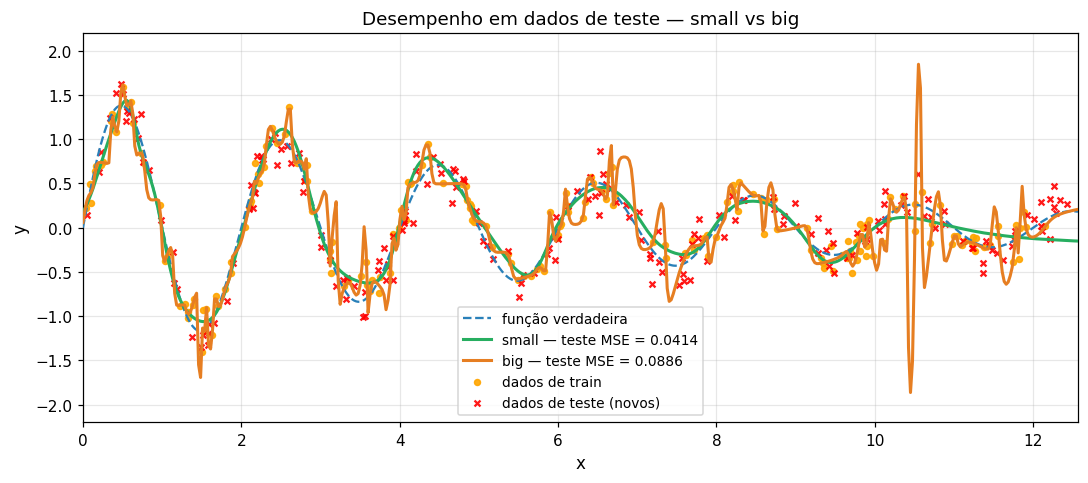

In [27]:
# ── Plotar: dados de teste + predições dos dois modelos ──────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9", label="função verdadeira", zorder=3)
ax.plot(x_grade, jax.vmap(modelo_b)(xg_in).squeeze(-1), "-", lw=2.0, color="#27ae60", label=f"small — teste MSE = {perda_teste_small:.4f}", zorder=4)
ax.plot(x_grade, jax.vmap(modelo_of)(xg_in).squeeze(-1), "-", lw=2.0, color="#e67e22", label=f"big — teste MSE = {perda_teste_big:.4f}", zorder=4)
ax.scatter(x_dados, y_ruidoso, s=15, alpha=0.9, color="orange", label="dados de train", marker='o', zorder=2)
ax.scatter(x_teste, y_teste_ruidoso, s=15, alpha=0.9, color="red", label="dados de teste (novos)", marker='x', zorder=2)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Desempenho em dados de teste — small vs big")
ax.legend(fontsize=9)
ax.set_xlim(0, float(X_MAX))
ax.set_ylim(-2.2, 2.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A rede pequena mantém desempenho semelhante no treino e no teste —
ela **generalizou**. A rede grande tem perda de treino baixíssima
(abaixo do piso do ruído!), mas no teste piora: ela **decorou o ruído**
em vez de aprender a função subjacente. Isso é o **sobreajuste** em ação.

---
## Extrapolação fora do domínio de treino

O modelo foi treinado com $x \in [0, 4\pi]$. Ele devolve predições para
qualquer $x$ — inclusive fora dessa faixa. Mas podemos confiar nelas?

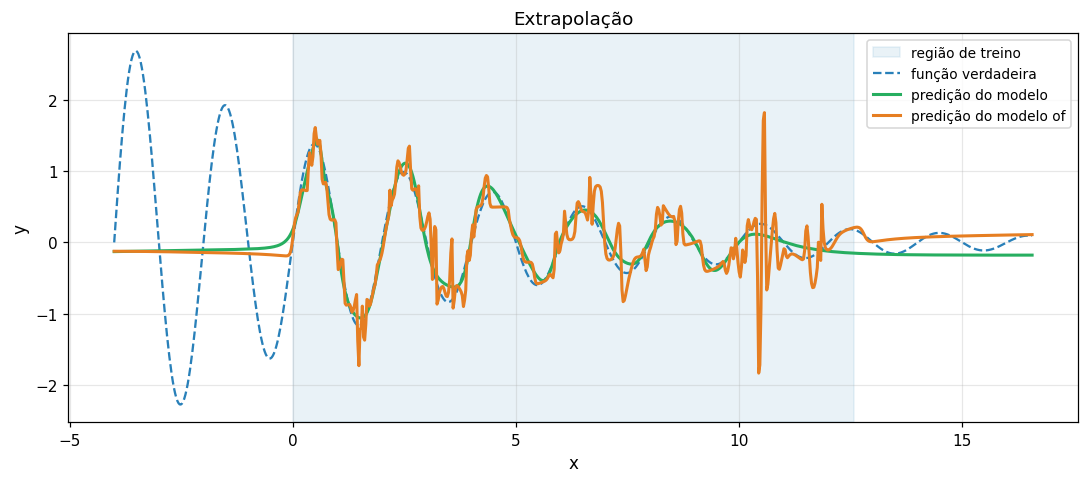

In [28]:
# ── Faixa estendida: ir além do domínio de treino ───────────────────────────
x_ext = jnp.linspace(-4.0, float(X_MAX) + 4.0, 800)
y_ext_verdadeiro = senoide_amortecida(x_ext)
x_ext_in = normalizar_x(x_ext).reshape(-1, 1)

y_ext_pred = jax.vmap(modelo_b)(x_ext_in).squeeze(-1)
y_ext_pred_of = jax.vmap(modelo_of)(x_ext_in).squeeze(-1)

fig, ax = plt.subplots(figsize=(10, 4.5))

# Sombrear a região de treino
ax.axvspan(0, float(X_MAX), alpha=0.10, color="#2980b9", label="região de treino")
ax.plot(x_ext, y_ext_verdadeiro, "--", lw=1.5, color="#2980b9", label="função verdadeira")
ax.plot(x_ext, y_ext_pred, "-", lw=2.0, color="#27ae60", label="predição do modelo")
ax.plot(x_ext, y_ext_pred_of, "-", lw=2.0, color="#e67e22", label="predição do modelo of")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Extrapolação")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Dentro da região de treino (sombreada), o modelo acompanha a função real.
Fora dela, diverge — às vezes suavemente, às vezes de forma dramática.

Isso é uma propriedade geral de redes neurais, não um defeito deste modelo
em particular: **o modelo não extrapola de forma confiável**. Ele sempre
devolve *algum* número, mas fora do suporte dos dados de treino esse número
é ditado pela arquitetura, não pela física — e o modelo falha **em silêncio**,
sem nenhum aviso de que saímos do território conhecido.

---
## Mudança de parâmetro: $\lambda$ ligeiramente diferente

E se os dados novos vierem da **mesma família de funções**, mas com um
parâmetro diferente? O modelo foi treinado com $\lambda = 2.0$; vamos
testá-lo com $\lambda = 2.5$.

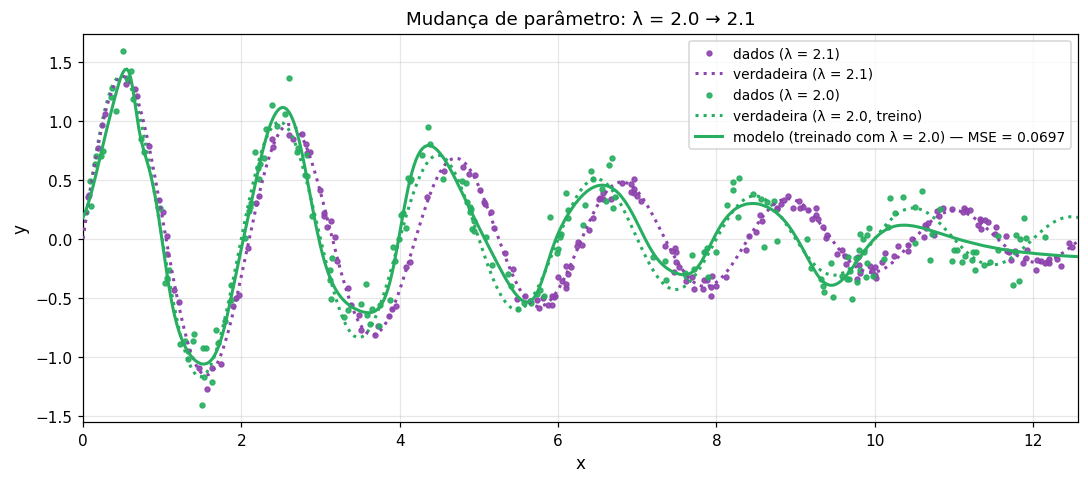

Perda no treino original (λ = 2.0) : 0.0189
Perda nos dados com λ = 2.1      : 0.0697


In [29]:
# ── Dados com lam diferente (mesmo intervalo de x) ──────────────────────────
LAM_SHIFT = 2.1
SIGMA_SHIFT = 0.05

y_grade_shift = senoide_amortecida(x_grade, lam=LAM_SHIFT)

k_shift_x, k_shift_ruido = jax.random.split(jax.random.PRNGKey(456))
x_shift = jnp.sort(jax.random.uniform(k_shift_x, (N_DADOS,), minval=0.0, maxval=float(X_MAX)))
y_shift_ruidoso = senoide_amortecida(x_shift, lam=LAM_SHIFT) + jax.random.normal(k_shift_ruido, (N_DADOS,)) * SIGMA_SHIFT

x_shift_in = normalizar_x(x_shift).reshape(-1, 1)
perda_shift = float(perda_eqx(modelo_b, x_shift_in, y_shift_ruidoso))

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.scatter(x_shift, y_shift_ruidoso, s=10, alpha=0.9, color="#8e44ad", label=f"dados (λ = {LAM_SHIFT})", zorder=2)
ax.plot(x_grade, y_grade_shift, ":", lw=2.0, color="#8e44ad", label=f"verdadeira (λ = {LAM_SHIFT})", zorder=3)

ax.scatter(x_dados, y_ruidoso, s=10, alpha=0.9, color="#27ae60", label=f"dados (λ = 2.0)", zorder=2)
ax.plot(x_grade, y_grade, ":", lw=2.0, color="#27ae60", label="verdadeira (λ = 2.0, treino)", zorder=2)

ax.plot(x_grade, jax.vmap(modelo_b)(xg_in).squeeze(-1), "-", lw=2.0, color="#27ae60", label=f"modelo (treinado com λ = 2.0) — MSE = {perda_shift:.4f}", zorder=4)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Mudança de parâmetro: λ = 2.0 → {LAM_SHIFT}")
ax.legend(fontsize=9)
ax.set_xlim(0, float(X_MAX))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Perda no treino original (λ = 2.0) : {perda_final_b:.4f}")
print(f"Perda nos dados com λ = {LAM_SHIFT}      : {perda_shift:.4f}")

O modelo degradou quando aplicado a dados com $\lambda = 2.5$ — mesmo
que a forma funcional seja idêntica e o intervalo de $x$ seja o mesmo.
Uma mudança pequena no processo gerador já basta para perder qualidade.

Na próxima aula, veremos que isso é um caso concreto de **domain shift**
(mudança de domínio): a distribuição dos dados muda entre treino e
aplicação, e o modelo degrada em silêncio. Aprenderemos técnicas de
**adaptação de domínio** para lidar com essa situação.